In [243]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter, ImageChops
import time
# from p_tqdm import p_map
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale, iradon

Размер изображения: 200×200


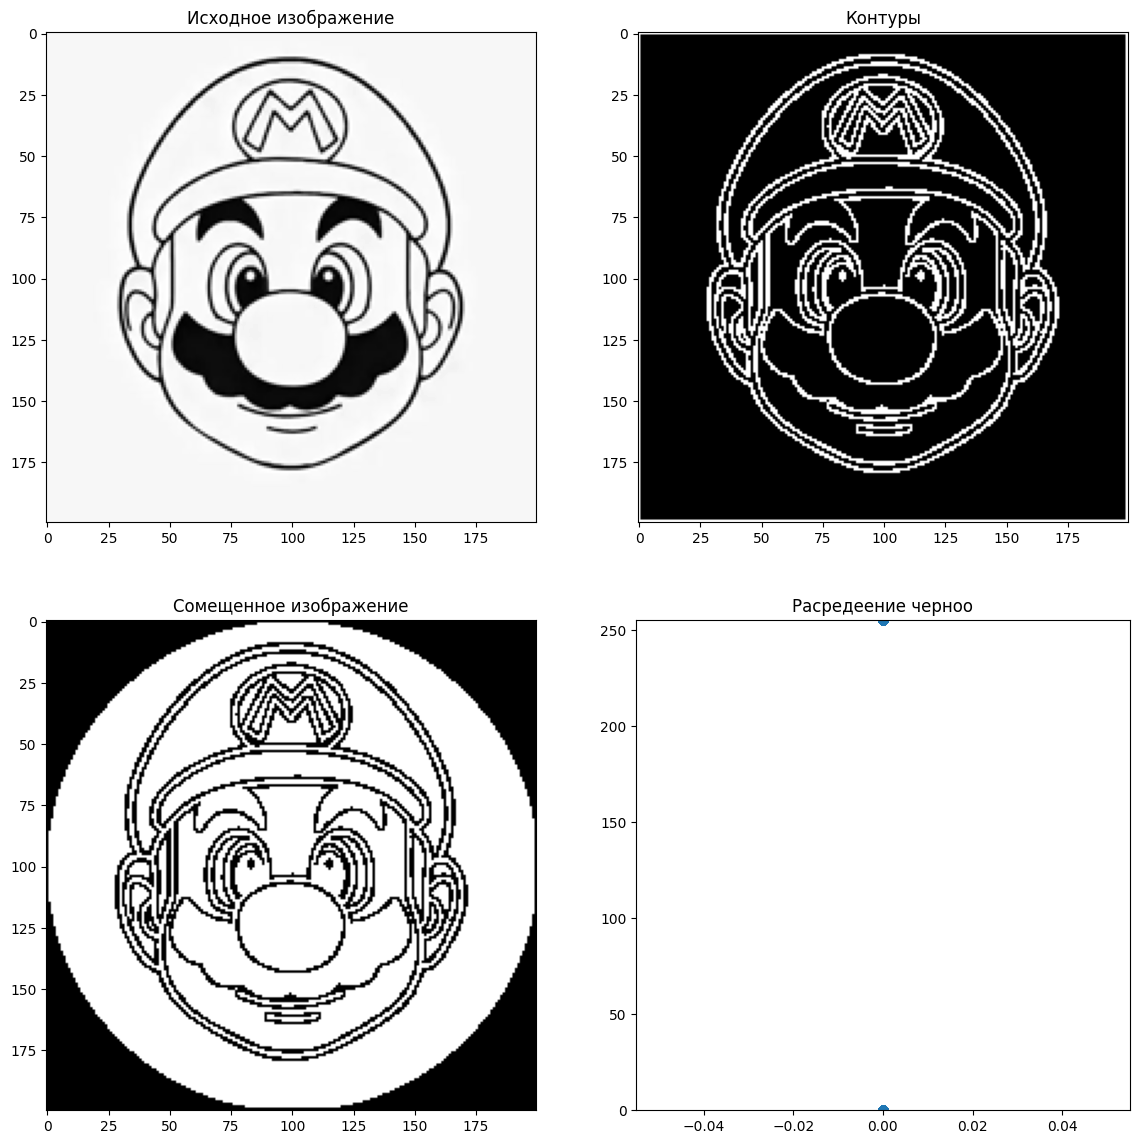

In [344]:
img = Image.open("local/StringArt/pic07.jpg").convert("L").resize((200,200))

img1 = ImageEnhance.Contrast(img).enhance(1.0)
img1 = np.array(img1)
img1 = img1 + (255 - np.max(img1)) 
img2 = ImageChops.invert(img.filter(ImageFilter.FIND_EDGES))
img2 = (np.array(img2) < 200) * 255
# a = np.clip(img1 - img2, 0, 255).astype(np.uint8)
# a = np.clip(img1, 0, 255).astype(np.uint8)
a = np.clip(255 - img2, 0, 255).astype(np.uint8)

dims = a.shape
c = np.array([dims[0]//2, dims[1]//2])
r = min(c)
print(f"Размер изображения: {2*r}×{2*r}")
b = np.array([[a[i+c[0]-r,j+c[1]-r] for j in range(2*r)] for i in range(2*r)])
mask = np.array([[((i-r)**2 + (j-r)**2 <= r**2) for j in range(2*r)] for i in range(2*r)])
ij = []
for i in range(2*r):
    for j in range(2*r):
        if mask[i,j]:
            ij.append([i, j])
ij_numpy = np.matrix(ij).T
ij_tuple = [i[0] for i in ij], [i[1] for i in ij]


fig, ax = plt.subplots(2, 2, figsize=(14, 14))
ax[0][0].imshow(img1, cmap='gray') 
ax[0][1].imshow(img2, cmap='gray') 
ax[1][0].imshow(Image.fromarray(b*mask, mode='L'), cmap='gray') 
tmp = b.ravel()
ax[1][1].scatter(np.zeros(len(tmp)), tmp) 
ax[1][1].set_ylim([0, 255])
ax[0][0].set_title("Исходное изображение")
ax[0][1].set_title("Контуры")
ax[1][0].set_title("Сомещенное изображение")
ax[1][1].set_title("Расредеение черноо")
plt.show()

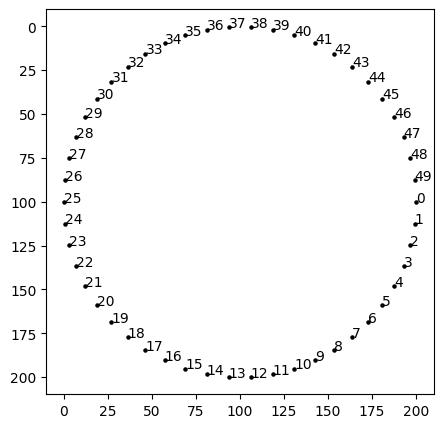

In [792]:
i_total = 50

node = [np.matrix([r + r*np.sin(i/i_total * 2*np.pi), r + r*np.cos(i/i_total * 2*np.pi)]).T for i in range(i_total)]
node_ang = np.array([i/i_total * 2*np.pi for i in range(i_total)])

fig = plt.figure(figsize=(5, 5))
for i in range(i_total):
    y, x = np.array(node[i].T)[0]
    plt.scatter(x, y, 5, 'k')
    plt.text(x, y, i)
plt.axis('equal')
plt.gca().invert_yaxis()
plt.show()

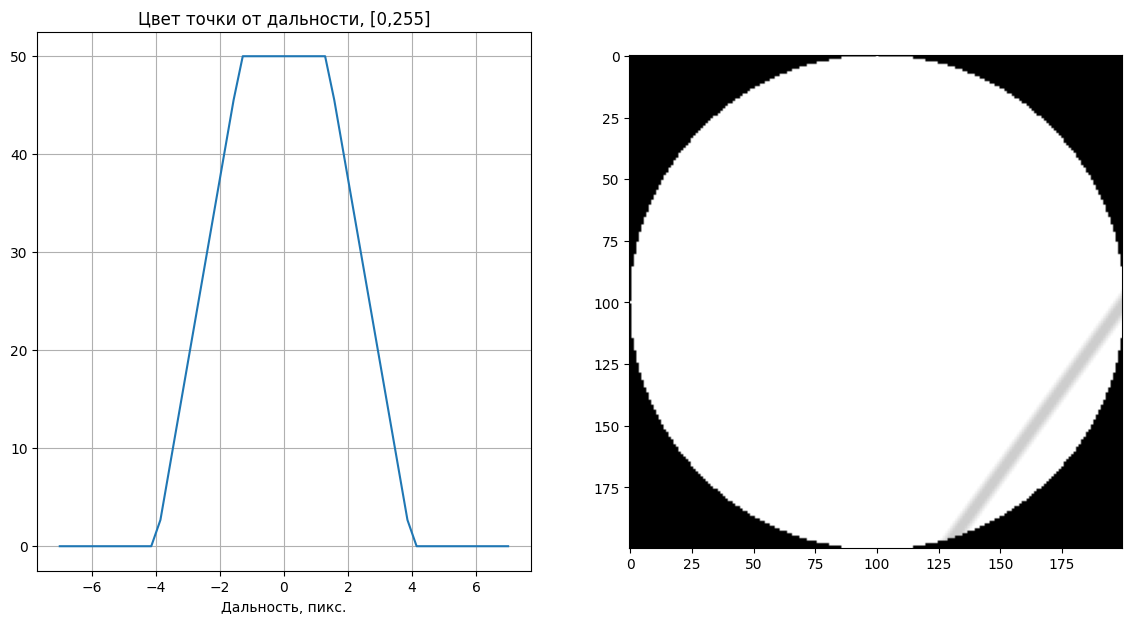

In [777]:
from numpy.linalg import norm

pixcol_c, pixcol_r0 = 50, 4
def pixcol(r):
    """Color of pixel by range r"""
    return np.clip(1.5*pixcol_c * (-np.abs(r)+pixcol_r0) / pixcol_r0,0,pixcol_c)
    # return np.clip(pixcol_c * (-np.abs(r)+pixcol_r0) / pixcol_r0,0,None)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
x = np.linspace(-7, 7)
ax1.plot(x, pixcol(x))
ax1.grid()
ax1.set_title("Цвет точки от дальности, [0,255]")
ax1.set_xlabel("Дальность, пикс.")

#def d(p1,p2,p3):
#    """Расстояние от линии [P1=(x1,y1), P2=(x2,y2)] до точки P3=(x3,y3)"""
#    return np.abs((np.flip((p2-p1).T) * ij_numpy + p1[1]*p2[0] - p1[0]*p2[1])) / norm(p2-p1)

def d(p1, p2, points):
    """Расстояние от линии [P1, P2] до точек points"""
    x1, y1 = p1
    x2, y2 = p2
    # points имеет shape (2, N) - [x_coords, y_coords]
    x3 = points[0]  # все x координаты
    y3 = points[1]  # все y координаты
    
    numerator = np.abs((y2-y1)*x3 - (x2-x1)*y3 + x2*y1 - y2*x1)
    anw = 1e2
    try:
        anw = numerator / norm(p2-p1)
    except RuntimeWarning:
        print(f"p1 = {p1}")
        print(f"p2 = {p2}")
        print(f"num = {numerator}")
        print(f"den = {norm(p2-p1)}")
    except:
        print("RuntimeWarning не сработал!!!")
        print(f"p1 = {p1}")
        print(f"p2 = {p2}")
        print(f"num = {numerator}")
        print(f"den = {norm(p2-p1)}")
    return anw

c = np.ones((2*r, 2*r))*255
p1 = node[0]
p2 = node[10]
c[ij_tuple] -= np.array(pixcol(d(p1, p2, ij_numpy)))[0]

ax2.imshow(Image.fromarray(c.astype(np.uint8)*mask, mode='L'), cmap='gray')
plt.show()

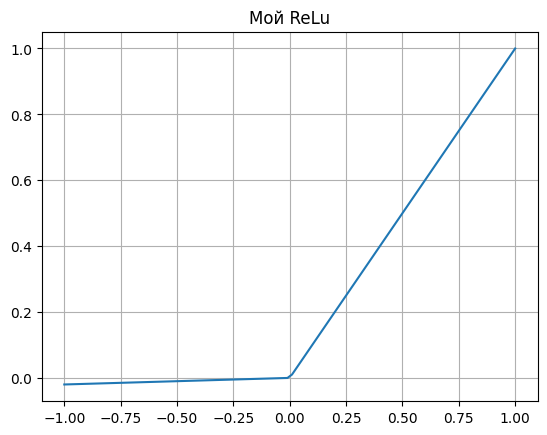

In [778]:
def show_results(image, alpha=0.05):
    # Отображение рассчитанных результатов
    N = len(sequence)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
    ax1.imshow(
        image,
        cmap=plt.cm.Greys_r,
        extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
        aspect='auto',
    )

    for i in range(N-1):
        i1 = sequence[i]
        i2 = sequence[i+1]
        x1, y1 = node[i1]
        x2, y2 = node[i2]
        ax2.plot([float(y1), float(y2)], [float(x1), float(x2)], 'k', alpha=alpha)
    ax2.axis('equal')
    ax2.yaxis.set_inverted(True)
    
    ax3.plot(loss)
    ax3.set_xlabel("Итерации / линии")
    ax3.set_ylabel("Loss")
    ax3.grid()
    
    plt.show()
    

def flatten(xss):
    return [x for xs in xss for x in xs]

def ReLu(x):
    # return np.clip(x, 0, None)
    return np.clip(x, None, 0) * 0.02 + np.clip(x, 0, None)

x = np.linspace(-1, 1, 100)
plt.title("Мой ReLu")
plt.plot(x, ReLu(x))
plt.grid()
plt.show()

##### New method (Radon transform)

min: 0.00, max: 15.93
size: (200, 50)


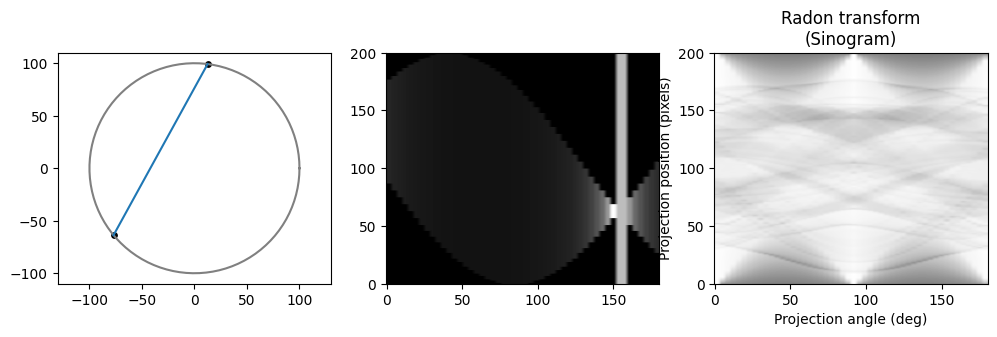

In [967]:
from numpy import cos, sin, arctan2, pi, sqrt

theta = np.linspace(0.0, 180.0, i_total, endpoint=False) 

def radon1line(a,s,a0,s0,R):
    if abs((a - a0 + 2*pi)%(2*pi))<1e-1:
        anw = 1e1
    elif (s**2 + s0**2 - 2*s*s0*cos(a-a0))/sin(a-a0)**2 > R**2:
        anw = 0
    else:
        anw = 1/np.abs(sin(a-a0))
    return anw  # + 1e2/((a-a0)**2 + 1)
    
i1 = 32
i2 = 1
x1,y1 = node[i1]; x2,y2 = node[i2]
x1=float(x1)-r;y1=float(y1)-r;x2=float(x2)-r;y2=float(y2)-r;
s0 = d(node[i1]-r, node[i2]-r, np.zeros(2))[0,0]
a0 = arctan2(y1+y2, x1+x2)
#if a0 < 0:
#    a0 = -a0
#    s0 = -s0

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))
tmp = np.linspace(0, 2*np.pi, 100)
ax1.plot(r*np.cos(tmp), r*np.sin(tmp), 'gray')
tmp = np.linspace(x1, x2, 10)
ax1.plot(tmp, (s0-tmp*cos(a0))/sin(a0))
ax1.scatter(x1, y1, 15, 'k')
ax1.scatter(x2, y2, 15, 'k')
ax1.set_xlim([-10, 2*r+10])
ax1.set_ylim(-10, 2*r+10)
ax1.axis('equal')

sinogram = np.zeros((2*r,i_total))
for s in range(2*r):
    for ia,a in enumerate(theta):
        sinogram[s,ia] += radon1line(a*pi/180,s-r,a0,s0,r)
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)
print(f"min: {np.min(sinogram):.2f}, max: {np.max(sinogram):.2f}")

sinogram = radon(image, theta=theta)
print(f"size: {sinogram.shape}")

dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax3.set_title("Radon transform\n(Sinogram)")
ax3.set_xlabel("Projection angle (deg)")
ax3.set_ylabel("Projection position (pixels)")
ax3.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)
plt.show()

In [928]:
s0, a0

(53.58267949789967, -0.31415926535897953)

In [922]:
a0*180/pi

342.0

In [940]:
s,a = np.unravel_index(benefit.argmax(), sinogram_remain.shape)
s,a 

(28, 0)

In [941]:
a = theta[a]*pi/180
s = np.linspace(-100,100,200,endpoint=False)[s]
s,a 

(-72.0, 0.0)

In [942]:
th1 = a - np.arccos(s/r)
th2 = a + np.arccos(s/r)
th1 = (th1 + 2*pi) % (2*pi)
th2 = (th2 + 2*pi) % (2*pi)
th1, th2

(3.90858666145166, 2.374598645727927)

In [895]:
node_ang

array([0.        , 0.12566371, 0.25132741, 0.37699112, 0.50265482,
       0.62831853, 0.75398224, 0.87964594, 1.00530965, 1.13097336,
       1.25663706, 1.38230077, 1.50796447, 1.63362818, 1.75929189,
       1.88495559, 2.0106193 , 2.136283  , 2.26194671, 2.38761042,
       2.51327412, 2.63893783, 2.76460154, 2.89026524, 3.01592895,
       3.14159265, 3.26725636, 3.39292007, 3.51858377, 3.64424748,
       3.76991118, 3.89557489, 4.0212386 , 4.1469023 , 4.27256601,
       4.39822972, 4.52389342, 4.64955713, 4.77522083, 4.90088454,
       5.02654825, 5.15221195, 5.27787566, 5.40353936, 5.52920307,
       5.65486678, 5.78053048, 5.90619419, 6.03185789, 6.1575216 ])

In [943]:
i_1 = np.argmin(np.abs(th1 - node_ang))
i_2 = np.argmin(np.abs(th2 - node_ang))
# i_1, i_2 = sorted([i_1, i_2])
i_1, i_2

(31, 19)

In [897]:
(th1 + 2*pi) % (2*pi)

3.9085866614516593

In [960]:
len(theta)

50

28 0
-72.0 0.0


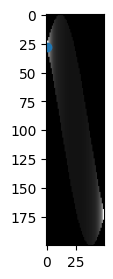

21 25
-79.0 90.0


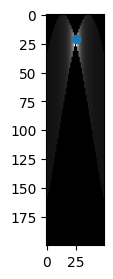

21 25
-79.0 90.0


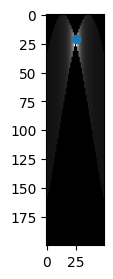

21 25
-79.0 90.0


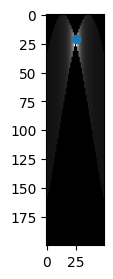

21 25
-79.0 90.0


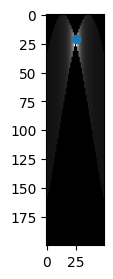

21 25
-79.0 90.0


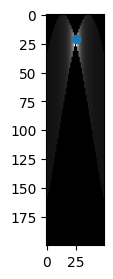

21 25
-79.0 90.0


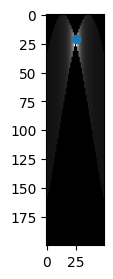

21 25
-79.0 90.0


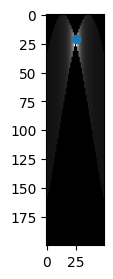

21 25
-79.0 90.0


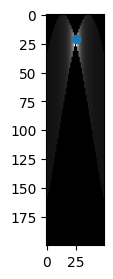

21 25
-79.0 90.0


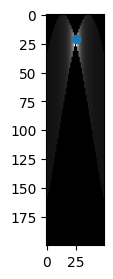

1.2 c | 0.02 min


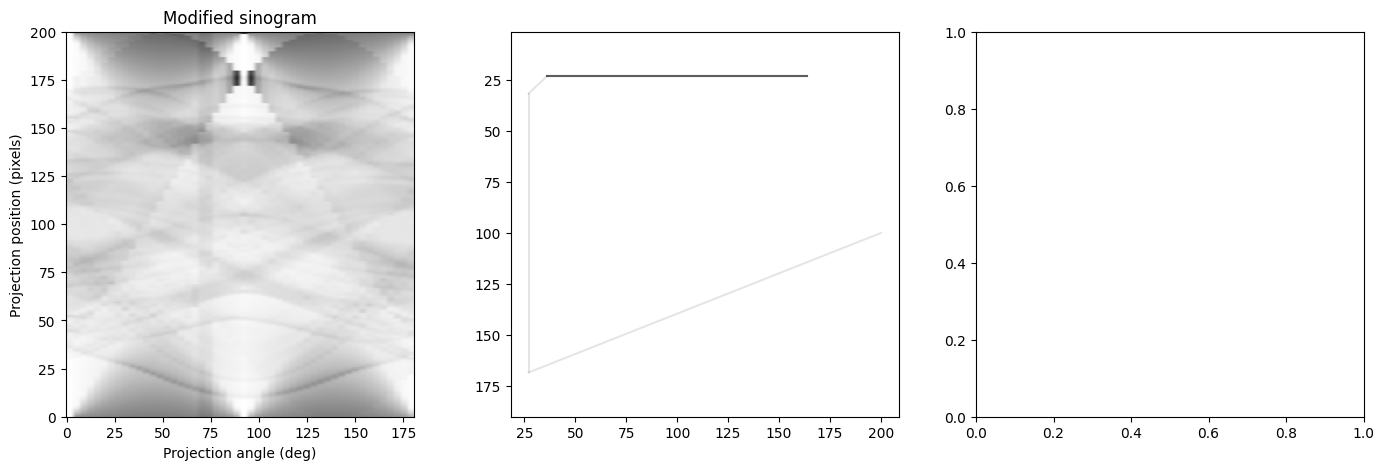

In [968]:
i1 = 0                           # Start node
image = img1                     # Image choice
pic = (np.ones((2*r, 2*r))*255)  # Firstly, we have blank image
sequence = [i1]                  # Node list docking
loss = []                        # Loss docking
N = 10                        # Number of lines


start_time = time.perf_counter()
sinogram_remain  = sinogram.copy()
L_array = np.array([[1+2*sqrt(r**2-s**2) for _ in theta] for s in np.linspace(-100,100,200,endpoint=False)])
for i in range(N):
    benefit = sinogram_remain # / L_array
    s_,a_ = np.unravel_index(benefit.argmax(), sinogram_remain.shape)
    print(s_,a_)
    a = theta[a_]*pi/180
    s = np.linspace(-100,100,200,endpoint=False)[s_]
    print(s,a/pi*180)
    
    th1 = a - np.arccos(s/r)
    th2 = a + np.arccos(s/r)
    th1 = (th1 + 2*pi) % (2*pi)
    th2 = (th2 + 2*pi) % (2*pi)
    
    i_1 = np.argmin(np.abs(th1 - node_ang))
    i_2 = np.argmin(np.abs(th2 - node_ang))
    i_1, i_2 = sorted([i_1, i_2])
    if i1 == i_1:
        #print(f"1")
        i2 = i_2
        seq = [[i1,i2]]
        i1 = i2
        sequence.append(i1)
    elif i1 == i_2:
        #print(f"2")
        i2 = i_1
        seq = [[i2,i1]]
        i1 = i2
        sequence.append(i1)
    else:
        #print(f"3")
        seq = [[i1, i_1], [i_1, i_2]]
        i1 = i_2
        sequence.append(i_1)
        sequence.append(i1)
        
    for i12 in seq:
        th1 = node_ang[i12[0]] 
        th2 = node_ang[i12[1]]
        a0 = (th1+th2)/2
        s0 = r*cos((th2-th1)/2)
        sinogram_delta = np.zeros(sinogram_remain.shape)
        for s in range(2*r):
            for ia,a in enumerate(theta):
                sinogram_delta[s,ia] += radon1line(a*pi/180,s-r,a0,s0,r)
        sinogram_remain -= sinogram_delta
        sinogram_remain = np.clip(sinogram_remain, 0, 255)

        # In circle area, marked my ij_mask, i add line to picture with pixcol function
        pic[ij_tuple] -= np.array(pixcol(d(node[i12[0]], node[i12[1]], ij_numpy)))[0]
        pic = np.clip(pic, 0, 255)  # Clip the picture
    # print(np.min(sinogram_remain), np.max(sinogram_remain))
    fig, ax1 = plt.subplots(1, 1, figsize=(3, 3))
    ax1.imshow(sinogram_delta,
               cmap=plt.cm.Greys_r,
               # extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy)
              )
    ax1.scatter(a_,s_)
    plt.show()

    
t = time.perf_counter() - start_time
print(f"{(t):.1f} c | {(t/60):.2f} min")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
ax1.imshow(sinogram_remain,
           cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy))
ax1.set_title("Modified sinogram")
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")

N = len(sequence)
for i in range(N-1):
    x1, y1 = node[sequence[i]]
    x2, y2 = node[sequence[i+1]]
    ax2.plot([float(y1), float(y2)], [float(x1), float(x2)], 'k', alpha=0.1)
ax2.axis('equal')
ax2.yaxis.set_inverted(True)

plt.show()

In [951]:
a,s

(176.4, 199)

In [953]:
sequence

[0, 19, 31, 32, 43, 32, 43, 32, 43, 32, 43, 32, 43]

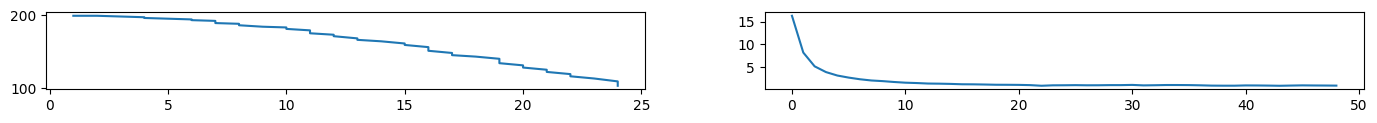

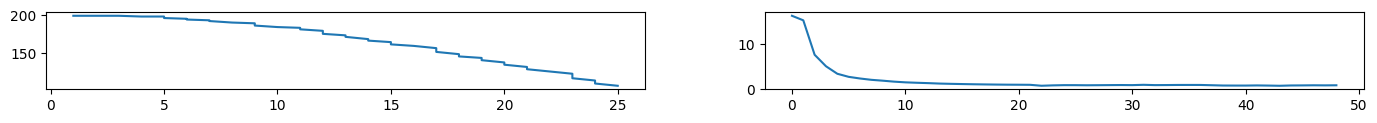

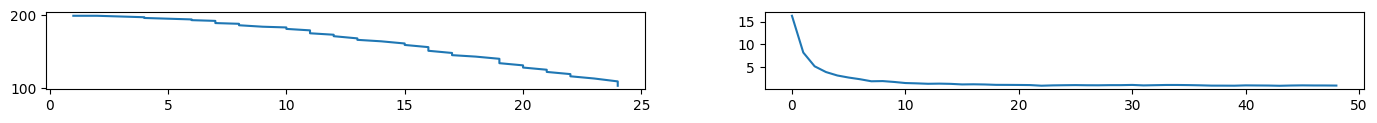

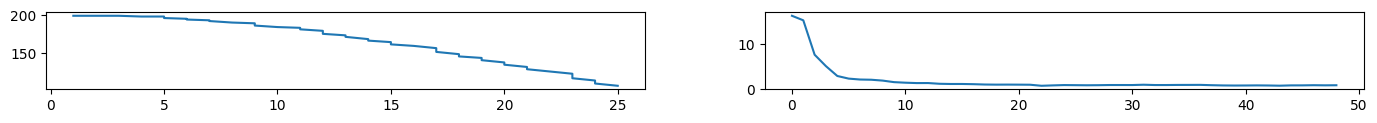

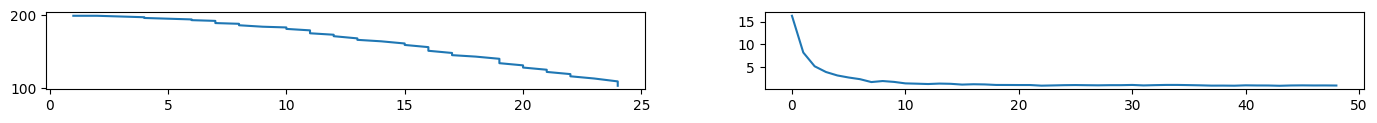

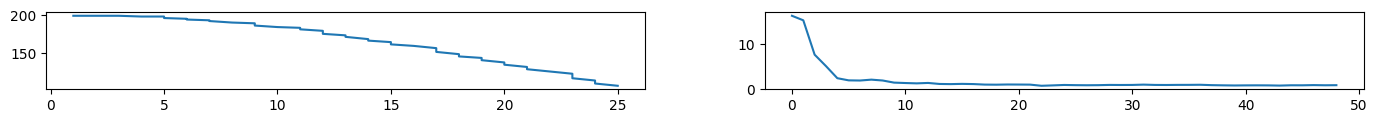

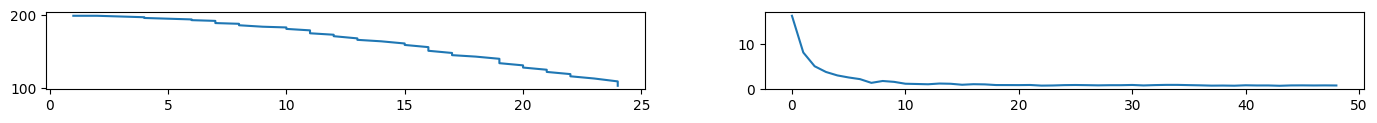

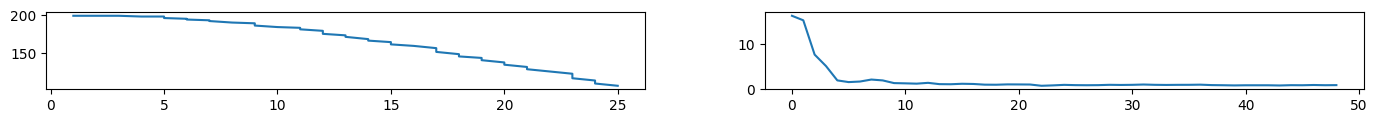

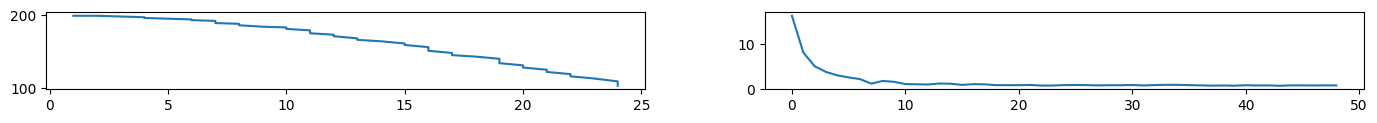

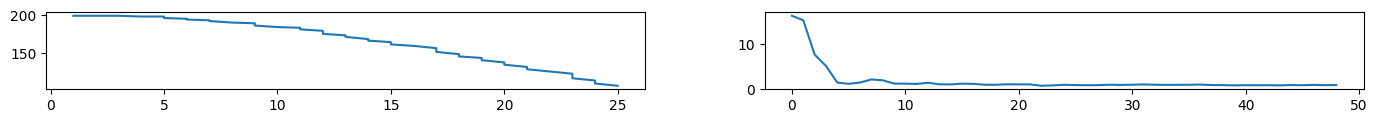

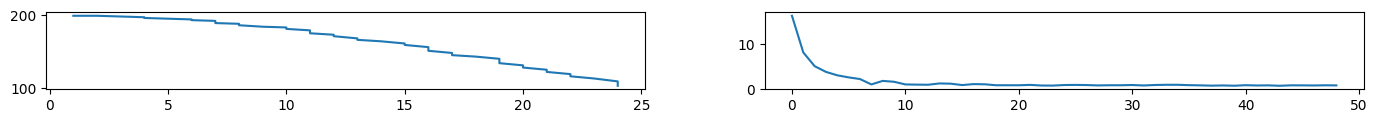

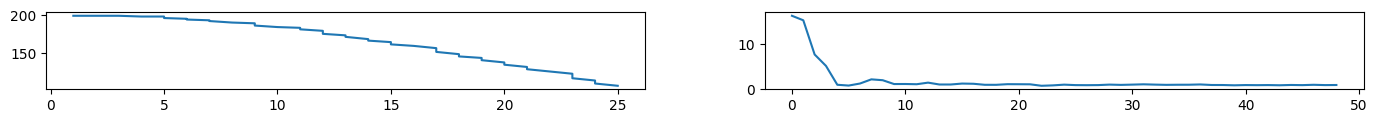

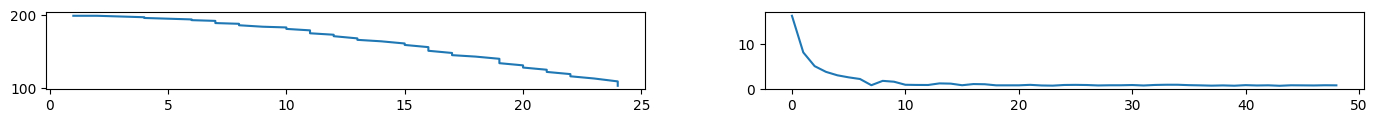

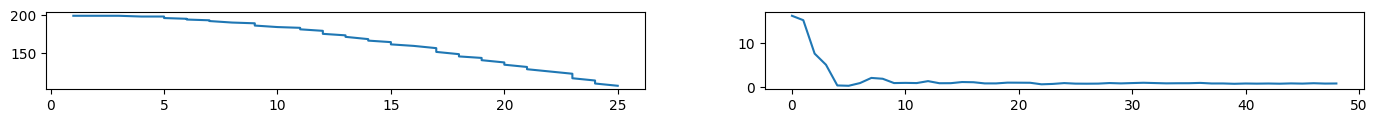

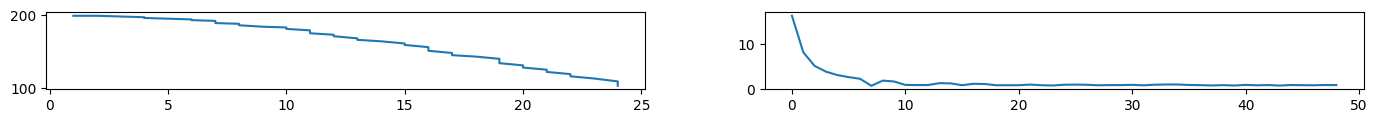

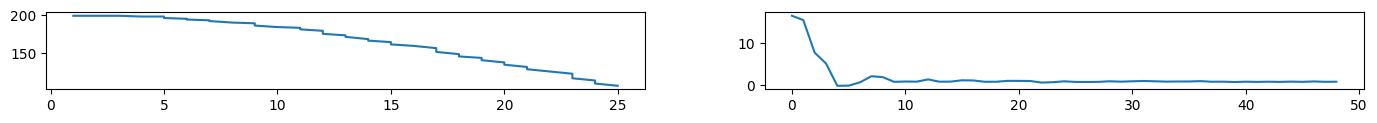

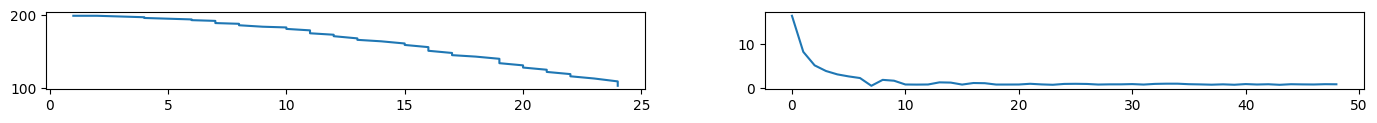

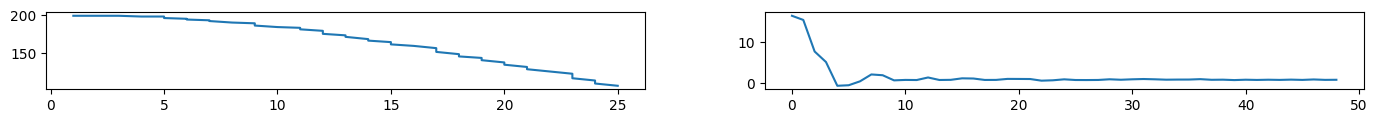

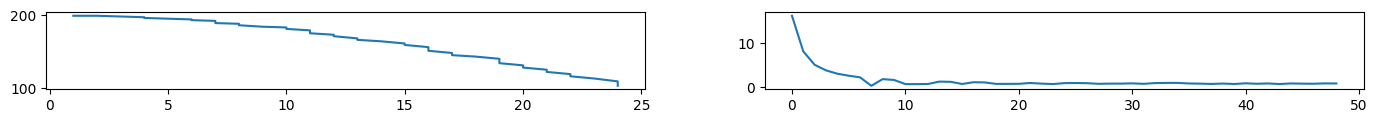

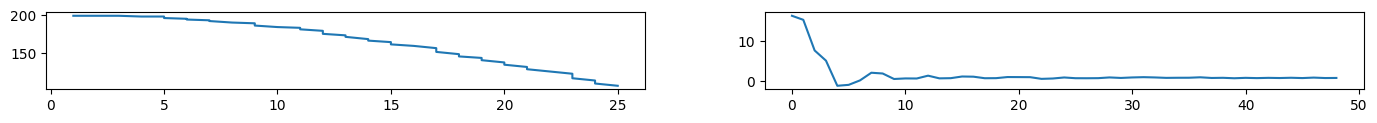

2.9 c (0.05) min


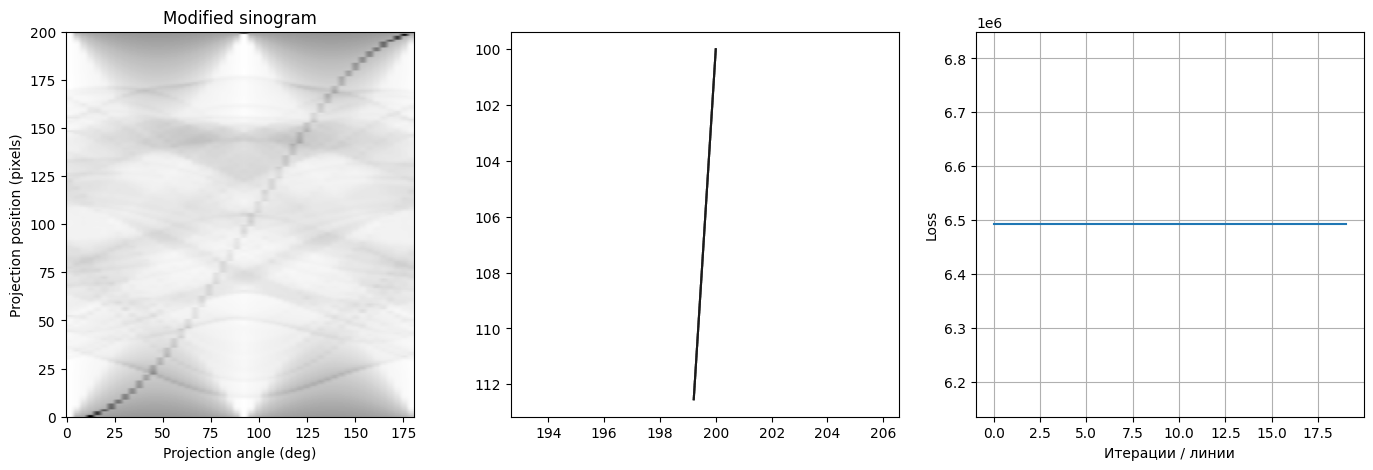

In [837]:
i1 = 0                           # Start node
image = img1                     # Image choice
pic = (np.ones((2*r, 2*r))*255)  # Firstly, we have blank image
sequence = [i1]                  # Node list docking
loss = []                        # Loss docking
N = 20                          # Number of lines


start_time = time.perf_counter()
sinogram_remain  = sinogram.copy()
for i in range(N):
    e_list = []
    next_candidates = np.array([i for i in range(i_total) if i!=i1])
    a_list, s_list = [], []
    for i2 in next_candidates:
        th1 = theta[i1]*pi/180
        th2 = theta[i2]*pi/180
        a = (th1+th2)/2
        s = r*cos((th2-th1)/2)
        L = 2*sqrt(r**2 - s**2)
        a = np.argmin(np.abs(theta - a*180/np.pi))
        s = np.argmin(np.abs(s - np.linspace(-100,100,200,endpoint=False)))
        a_list.append(a)
        s_list.append(s)
        e_list.append(sinogram_remain[s,a] / L) 
    i2 = next_candidates[e_list.index(max(e_list))]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 1))
    ax1.plot(a_list,s_list)
    ax2.plot(e_list)
    plt.show()
        
    th1 = theta[i1]*pi/180
    th2 = theta[i2]*pi/180
    a0 = (th1+th2)/2
    s0 = r*cos((th2-th1)/2)
    for s in range(2*r):
        for ia,a in enumerate(theta):
            sinogram_remain[s,ia] -= radon1line(a*pi/180,s-r,a0,s0,r)
    
    # In circle area, marked my ij_mask, i add line to picture with pixcol function
    pic[ij_tuple] -= np.array(pixcol(d(node[i1], node[i2], ij_numpy)))[0]
    pic = np.clip(pic, 0, 255)  # Clip the picture
    
    # break
    
    # Docking
    e = np.sum(delta_pic)
    loss.append(e)
    i1 = i2
    sequence.append(i1)

    
t = time.perf_counter() - start_time
print(f"{(t):.1f} c ({(t/60):.2f}) min")

N = len(sequence)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
ax1.imshow(sinogram_remain,
           cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy))
ax1.set_title("Modified sinogram")
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")

for i in range(N-1):
    i1 = sequence[i]
    i2 = sequence[i+1]
    x1, y1 = node[i1]
    x2, y2 = node[i2]
    ax2.plot([float(y1), float(y2)], [float(x1), float(x2)], 'k', alpha=0.1)
ax2.axis('equal')
ax2.yaxis.set_inverted(True)

ax3.plot(loss)
ax3.set_xlabel("Итерации / линии")
ax3.set_ylabel("Loss")
ax3.grid()

plt.show()



In [769]:
sequence

[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

##### New method (Radon transform)

0.63 rad | 36.00 deg
i1=0, i2=10
delta=0.9045084971874737


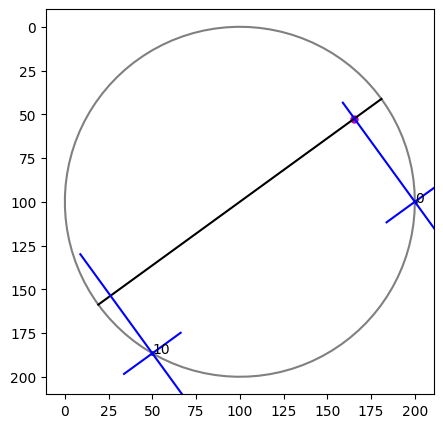

In [444]:
i1 = 0
th = 10
th_deg = theta[th]
th_rad = theta[th]/180*np.pi
print(f"{(th_rad):.2f} rad | {(th_deg):.2f} deg")
i2 = (-i1 + th + i_total)%i_total
# i2 = (int(i1*3 + 2*th/3) + 50)%50
i_ = [i1, i2]
print(f"i1={i1}, i2={i2}")
delta = (1+np.cos(th_rad)) / 2
print(f"delta={delta}")

fig = plt.figure(figsize=(5, 5))
tmp = np.linspace(0, 2*np.pi, 100)
plt.plot(100+100*np.cos(tmp), 100+100*np.sin(tmp), 'gray')
r0 = np.array([100-100*np.cos(-th_rad), 100-100*np.sin(-th_rad)])
r1 = np.array([100+100*np.cos(-th_rad), 100+100*np.sin(-th_rad)])
plt.plot([r0[0], r1[0]], 
         [r0[1], r1[1]], 'k')
plt.scatter(*(r0*(1-delta)+r1*delta), 25, 'm')
for i in i_:
    y, x = np.array(node[i].T)[0]
    plt.scatter(x, y, 5, 'k')
    plt.plot([x-20*np.cos(-th_rad), x+20*np.cos(-th_rad)], 
             [y-20*np.sin(-th_rad), y+20*np.sin(-th_rad)], 'b')
    plt.plot([x-70*np.sin(-th_rad), x+70*np.sin(-th_rad)], 
             [y+70*np.cos(-th_rad), y-70*np.cos(-th_rad)], 'b')
    plt.text(x, y, i)
plt.axis('equal')
plt.xlim([-10, 210])
plt.ylim([-10, 210])
plt.gca().invert_yaxis()
plt.show()

size: (200, 30)


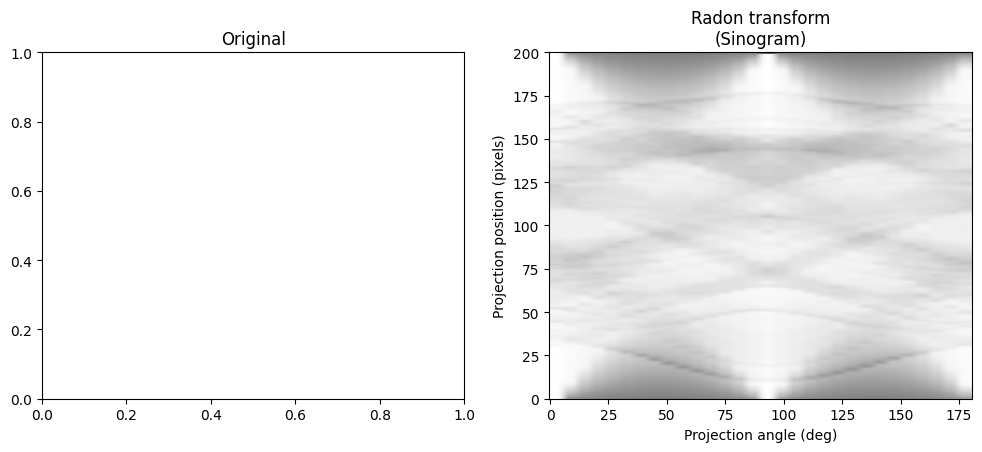

In [457]:
image = img1

# theta = np.linspace(0.0, 180.0, max(image.shape), endpoint=False)  
theta = np.linspace(0.0, 180.0, i_total, endpoint=False)  
sinogram = radon(image, theta=theta)
print(f"size: {sinogram.shape}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# plt.imshow(Image.fromarray(sinogram.astype(np.uint8), mode='L'), cmap='gray') 
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax1.set_title("Original")
# ax1.imshow(image, cmap=plt.cm.Greys_r)
ax2.set_title("Radon transform\n(Sinogram)")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)
plt.show()

size: (200, 30)


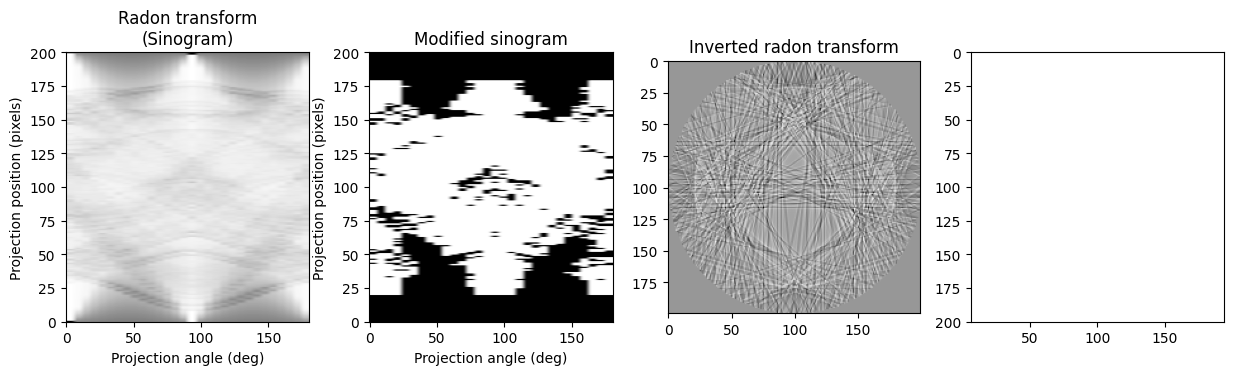

In [478]:
N = 1500

theta = np.linspace(0.0, 180.0, i_total, endpoint=False)  
sinogram = radon(image, theta=theta)
print(f"size: {sinogram.shape}")

data = []
# new_sinogram = np.where(sinogram > 50, sinogram, 0)
new_sinogram = np.where(sinogram > 150, 1, 0)
for point in range(sinogram.shape[0]):
    for th in range(sinogram.shape[1]):
        if not (20<point<180):
            # data.append([sinogram[point,th],point,th])
        # else:
            new_sinogram[point,th] = 0
data = sorted(data, reverse=False)[:N]

# new_sinogram = np.ones(sinogram.shape)*255
# new_sinogram = sinogram.copy() * 0  # + 100
seq = set()
seq2 = []
for i in range(len(data)):
    # new_sinogram[data[i][1], data[i][2]] = data[i][0]
    delta = data[i][1] / sinogram.shape[0] * 2
    th = data[i][2]
    beta = np.arccos(1 - delta)
    be   = np.argmin(np.abs(theta - beta*180/np.pi))
    i1 = th + i_total/2 - be
    i2 = th + i_total/2 + be
    
#     p2mp1 = np.arccos(delta - 1)
#     idx = np.argmin(np.abs(theta - p2mp1*180/np.pi))
#     i2mi1 = idx
#     i2pi1 = data[i][2] * 2
#     i1 = int((i2pi1 - i2mi1) / 2)
#     i2 = int((i2pi1 + i2mi1) / 2)
    i1 = (int(i1) + i_total)%i_total
    i2 = (int(i2) + i_total)%i_total
    seq.add(tuple(sorted((i1,i2))))
    seq2.append([i1,i2])
    # print(i1, i2)
    
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 3.5))
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax1.imshow(sinogram,
           cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy))
ax1.set_title("Radon transform\n(Sinogram)")
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")
ax2.imshow(new_sinogram,
           cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy))
ax2.set_title("Modified sinogram")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")

pic = iradon(new_sinogram, theta=theta, filter_name='ramp')
ax3.imshow(pic, cmap=plt.cm.Greys_r)
ax3.set_title("Inverted radon transform")

seq = list(seq)
for i in range(len(seq)-1):
    i1 = seq[i][0]
    i2 = seq[i][1]
    r1 = np.array(node[i1])
    r2 = np.array(node[i2])
    ax4.plot([r1[0], r2[0]], [r1[1], r2[1]], 'k', alpha=0.1)
    # ax4.plot([r1[1], r2[1]], [r1[0], r2[0]], 'k', alpha=0.1)
ax4.axis('equal')
ax4.set_xlim([0, 200])
ax4.set_ylim([0, 200])
ax4.yaxis.set_inverted(True)

plt.show()

size: (200, 30)


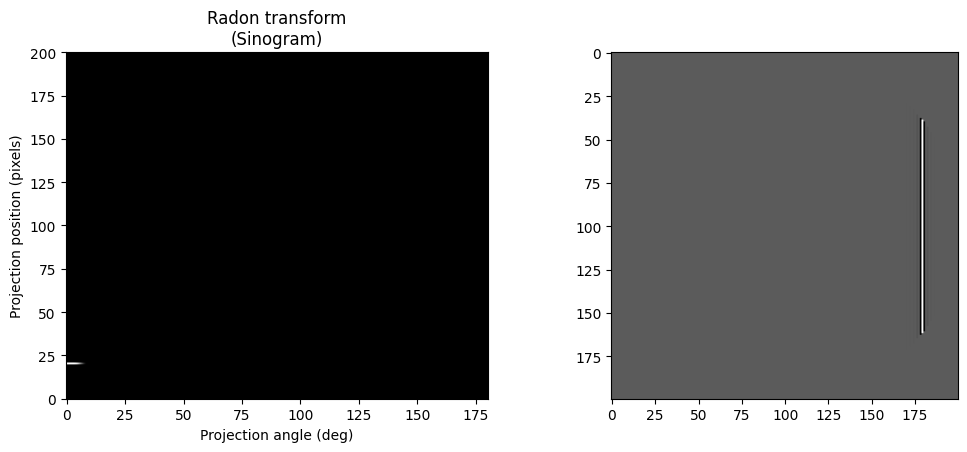

In [455]:
image = b

theta = np.linspace(0.0, 180.0, i_total, endpoint=False)  
sinogram = radon(image, theta=theta)
print(f"size: {sinogram.shape}")

sinogram = np.zeros(sinogram.shape)

th = 0
delta = 0.9
point = int(sinogram.shape[0]*delta)-1
sinogram[point,th] = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.set_title("Radon transform\n(Sinogram)")
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax1.imshow(sinogram,
           cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
           aspect='auto')

pic = iradon(sinogram, theta=theta, filter_name='ramp')
ax2.imshow(pic, cmap=plt.cm.Greys_r)
plt.show()

**Semi-retard algo**

/tmp/ipykernel_2500511/1929601596.py:33: RuntimeWarning: invalid value encountered in divide
  anw = numerator / norm(p2-p1)


1.7 c (0.03) min


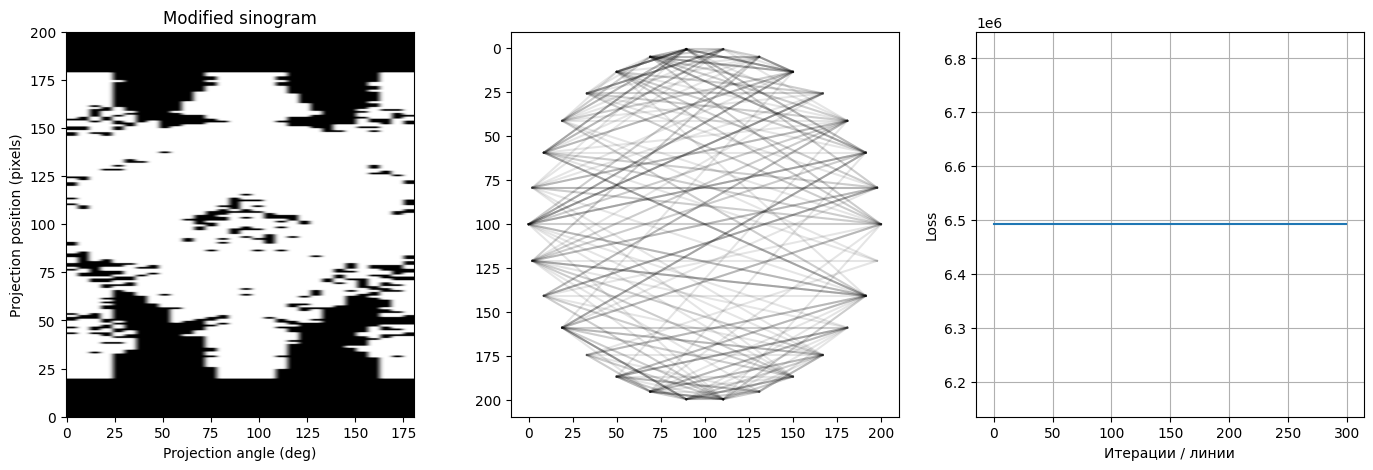

In [511]:
import random

i1 = 0                           # Start node
image = img1                     # Image choice
pic = (np.ones((2*r, 2*r))*255)  # Firstly, we have blank image
sequence = [i1]                  # Node list docking
loss = []                        # Loss docking
N = 300                          # Number of lines

THASHOLD = 120

start_time = time.perf_counter()
sinogram_new  = np.where(sinogram > THASHOLD, sinogram, 0)
for i in range(N):
    i2_list = []
    weights = []
    for j,th in enumerate(theta):
        i2 = (j - i1 + i_total)%i_total
        th_rad = th/180*np.pi
        delta = (1 - np.cos(th_rad)) / 2
        point = int(error_sinogram.shape[0] * delta) - 1
        if sinogram_new[point,j] > 0:
            i2_list.append(i2)
            weights.append(sinogram_new[point,j] - THASHOLD)
    i2 = random.choices(i2_list, weights=weights, k=1)[0]
    
    # In circle area, marked my ij_mask, i add line to picture with pixcol function
    pic[ij_tuple] -= np.array(pixcol(d(node[i1], node[i2], ij_numpy)))[0]
    pic = np.clip(pic, 0, 255)  # Clip the picture
    
    # break
    
    # Docking
    e = np.sum(delta_pic)
    loss.append(e)
    i1 = i2
    sequence.append(i1)

t = time.perf_counter() - start_time
print(f"{(t):.1f} c ({(t/60):.2f}) min")

N = len(sequence)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
ax1.imshow(new_sinogram,
           cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy))
ax1.set_title("Modified sinogram")
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")

for i in range(N-1):
    i1 = sequence[i]
    i2 = sequence[i+1]
    x1, y1 = node[i1]
    x2, y2 = node[i2]
    ax2.plot([float(y1), float(y2)], [float(x1), float(x2)], 'k', alpha=0.1)
ax2.axis('equal')
ax2.yaxis.set_inverted(True)

ax3.plot(loss)
ax3.set_xlabel("Итерации / линии")
ax3.set_ylabel("Loss")
ax3.grid()

plt.show()



0.1 c (0.00) min


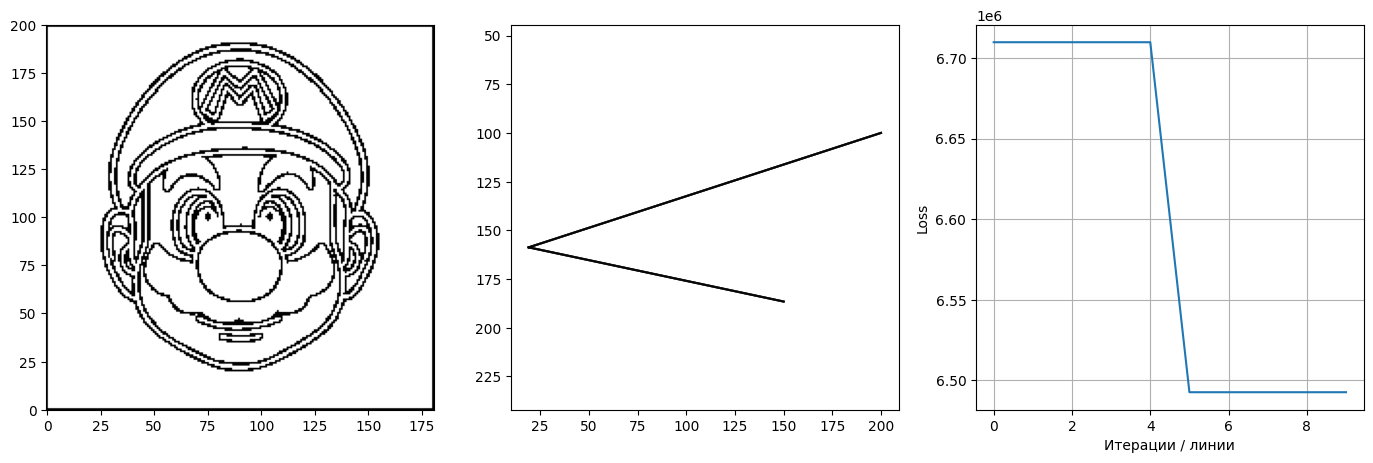

In [462]:
i1 = 0                           # Start node
image = img1                     # Image choice
pic = (np.ones((2*r, 2*r))*255)  # Firstly, we have blank image
sequence = [i1]                  # Node list docking
loss = []                        # Loss docking
N = 10                           # Number of lines

start_time = time.perf_counter()
for i in range(N):
    # The sinogram of current picture error
    # delta_pic = np.clip(pic-image, 0, 255)
    if i%5==0:
        delta_pic = np.clip(ReLu(image+pic-255)*mask, 0, 255)
        error_sinogram = radon(delta_pic, theta=theta)
    e_tmp = []
    points = []
    for j,th in enumerate(theta):
        i2 = (j - i1 + i_total)%i_total
        th_rad = th/180*np.pi
        delta = 1 - np.cos(th_rad)
        point = int(error_sinogram.shape[0] / 2 * delta) - 1
        points.append(point)
        if 20<point<180:
            e_tmp.append(error_sinogram[point, j])
        else:
            e_tmp.append(0)
    th_best = e_tmp.index(max(e_tmp))
    i2 = (th_best - i1 + i_total)%i_total
    #plt.plot(theta, points)
    #plt.show()
    
    # Find the best angle
    # projection_strength = np.max(error_sinogram, axis=0)
    # selected_theta_idx = np.argmin(projection_strength)
    
    # I understood that next node is selected_theta_idx
#     if selected_theta_idx == i1:
#         i2 = (selected_theta_idx + 25) % 50
#     else:
#         i2 = selected_theta_idx
    # i2 = (i1 - selected_theta_idx + 50)%50
    
    # In circle area, marked my ij_mask, i add line to picture with pixcol function
    pic[ij_tuple] -= np.array(pixcol(d(node[i1], node[i2], ij_numpy)))[0]
    pic = np.clip(pic, 0, 255)  # Clip the picture
    
    # break
    
    # Docking
    e = np.sum(delta_pic)
    loss.append(e)
    i1 = i2
    sequence.append(i1)

t = time.perf_counter() - start_time
print(f"{(t):.1f} c ({(t/60):.2f}) min")
show_results(image, alpha=0.5)

In [ ]:
# Сохранение
name = "Al1"

with open(f"local/StringArt/{name}.txt", "w") as f:
    f.write(f"im_size {r}\n")
    f.write(f"pixcol_c {pixcol_c}\n")
    f.write(f"pixcol_r0 {pixcol_r0}\n\n")
    f.write(f"Lines amount {counter}\n")
    f.write(f"Nodes amount {i_total}\n\n")
    f.write(f"Sequence: {i_total}\n")
    for j,i in enumerate(sequence):
        f.write(f"{j+1}) node {i}\n")
        
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(img1, cmap='gray') 
for i in range(len(sequence)-1):
    i1 = sequence[i]
    i2 = sequence[i+1]
    x1, y1 = node[i1]
    x2, y2 = node[i2]
    ax2.plot([float(y1), float(y2)], [float(x1), float(x2)], 'k', alpha=0.1)
ax2.axis('equal')
ax2.yaxis.set_inverted(True)
plt.savefig(f"local/StringArt/{name}.jpg")

##### Old method

In [ ]:
def get_e_by_node(i1, i2_list):
    e = []
    for i2 in i2_list:
        c = pic.copy()
        c[ij_tuple] -= np.array(pixcol(d(node[i1], node[i2], ij_numpy)))[0]
        # tmp = (np.abs(c-b)*mask).astype(np.uint8)
        tmp = (np.abs(ReLu(c-b))*mask).astype(np.uint8)
        e.append([i2, np.sum(tmp)])
    return e

In [ ]:
# Инициализация рассчёта
i1 = 0
pic = np.ones((2*r, 2*r))*255
sequence = [i1]
loss = []
counter = 0

In [ ]:
# Рассчёт / дорассчёт
N = 4000
N_cpu = 5
counter_prev = counter
start_time = time.perf_counter()
surplus_max = surplus = 5

for _ in range(N):
    counter += 1
    next_candidates = np.array([i for i in range(i_total) if i!=i1])
    parts = np.array_split(next_candidates, N_cpu)
    e = p_map(get_e_by_node, 
              [i1 for _ in range(N_cpu)], 
              [i for i in parts], disable=True)
    e = [i[1] for i in sorted(flatten(e))]
    
    i2_best = next_candidates[e.index(min(e))]
    loss.append(min(e))
    pic[ij_tuple] -= np.array(pixcol(d(node[i1], node[i2_best], ij_numpy)))[0]
    pic = np.clip(pic, 0, 255)
    i1 = i2_best
    sequence.append(i1)
    if counter > 10:
        if (loss[-1] > loss[-2]) or (loss[-1]/loss[0] < 0.01):
            surplus -= 1
            if surplus <= 0:
                print(f"Достигнут предел точности!")
                break
        else:
            surplus = surplus_max
    
    if counter%500==0:
        show_results()
    
    if (counter%100==0) or (counter-counter_prev==1):
        end_time = time.perf_counter()
        t = end_time - start_time
        print(f"{counter} / [{counter_prev} -> {N + counter_prev}] | loss={loss[-1]} ({int(100*loss[-1]/loss[0])}%) | {(t):.1f} c ({(t/60):.2f}) мин")

In [ ]:
show_results()

plt.plot(loss)
plt.xlabel("Итерации / линии")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
# Сохранение
name = "Al"

with open(f"local/StringArt/{name}.txt", "w") as f:
    f.write(f"im_size {r}\n")
    f.write(f"pixcol_c {pixcol_c}\n")
    f.write(f"pixcol_r0 {pixcol_r0}\n")
    f.write(f"iterations {counter}\n")
    f.write(f"nodes: {i_total}\n\n")
    for i in sequence:
        f.write(f"{i}\n")
        
fig = plt.figure(figsize=(20, 20))
for i in range(len(sequence)-1):
    i1 = sequence[i]
    i2 = sequence[i+1]
    x1, y1 = node[i1]
    x2, y2 = node[i2]
    plt.plot([float(y1), float(y2)], [float(x1), float(x2)], 'k', alpha=0.5)
plt.axis('equal')
plt.gca().invert_yaxis()
plt.savefig(f"local/StringArt/{name}.jpg")